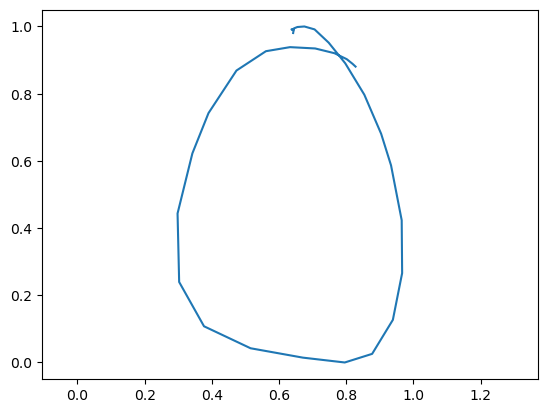

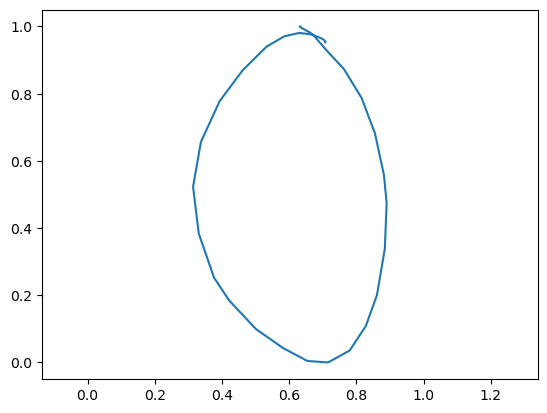

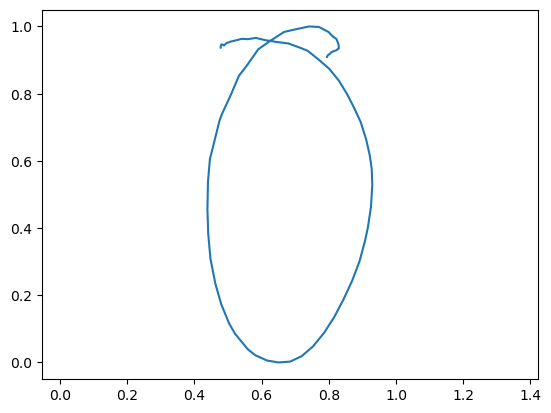

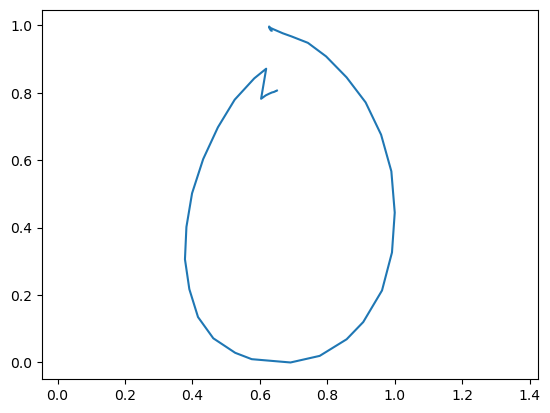

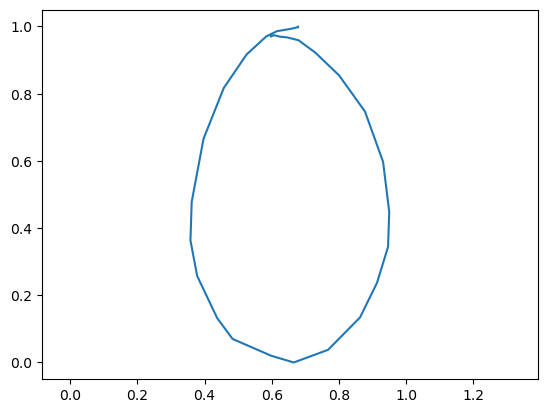

In [26]:
import os 
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

dir_path = "training_data"
file_paths = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and "stroke_0" in f]

dfs = [pd.read_csv(f, header=None) for f in file_paths]

samples = []
for df in dfs[:5]: 

    # Scale data
    X = df.to_numpy()
    X_scaled = StandardScaler().fit_transform(X)

    # Fit PCA
    X_pca = PCA(n_components=3).fit_transform(X)
    
    # Scale the data to range [0, 1] (min-max-scaling)
    X_pca_scaled = (X_pca - np.min(X_pca))/ (np.max(X_pca) - np.min(X_pca))
    samples.append(X_pca_scaled)

    # Plot the reduced data
    plt.figure()
    plt.plot(X_pca_scaled[:, 1], X_pca_scaled[:, 0])
    plt.axis("equal")
    plt.show()

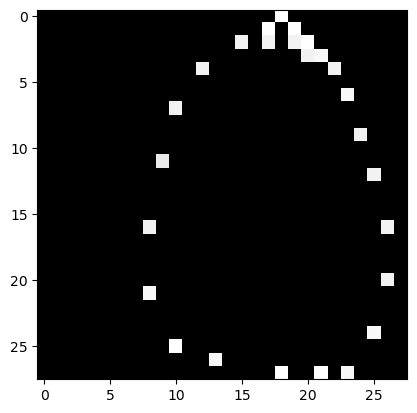

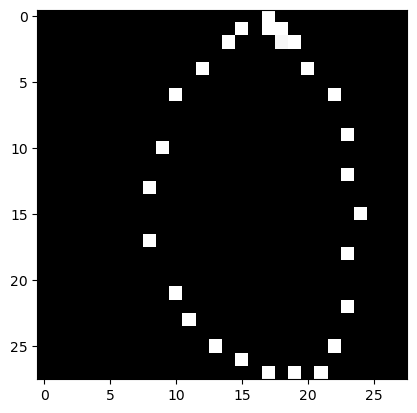

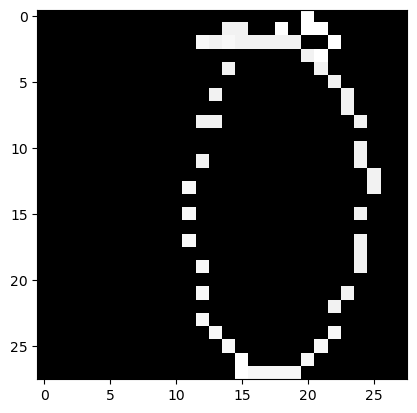

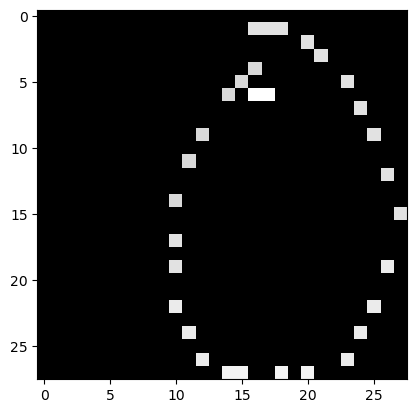

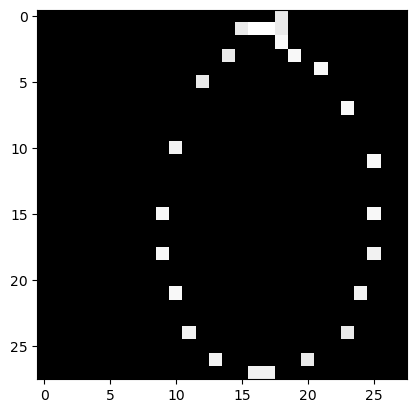

In [27]:
N = 28 # This is image width/height (square "images")

# Rescale samples to [0, N-1] (indices 0,...,(N-1) in the image)
indices = [(s * (N-1)).astype(int) for s in samples]

# Prepare empty (N x N) matrices for the "images"
X = [np.zeros([N, N]) for _ in range(len(indices))]

# Set "pixels" at "indices" to 1
for x, idx in zip(X, indices): 
    x[-idx[:, 0]-1, idx[:, 1]] = idx[:, 2] # Color the dots with the "z-axis" value
    x = np.rot90(x, 2)

# Plot the "images"
for x in X:
    plt.figure();  
    plt.imshow(x, cmap="Greys_r")